<a href="https://colab.research.google.com/github/ryadavnitb/Batch-7/blob/Erra-Sanjana/AirFlyInsightsDataVisualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**AirFly Insights: Data Visualization and Analysis of Airline Operations**

Dataset link: https://www.kaggle.com/datasets/usdot/flight-delays/data

Dataset Name: 2015 Flight Delays and Cancellations

**Milestone 1: Data Foundation and Cleaning**

**Week 1: Project Initialization and Dataset Setup**

•	Define goals, KPIs, and workflow

•	Load CSVs using pandas

•	Explore schema, types, size, and nulls

•	Perform sampling and memory optimizations

**Week 2: Preprocessing and Feature Engineering**

•	Handle nulls in delay and cancellation columns

•	Create derived features: Month, Day of Week, Hour, Route

•	Format datetime columns

•	Save preprocessed data for fast reuse

**Deliverables:**

•	Cleaned dataset

•	Summary of preprocessing logic

•	Feature dictionary


**Load CSVs using pandas**

In [ ]:
# Import pandas library for data loading and analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load flights dataset
flights = pd.read_csv('/content/flights.csv')

# Load airlines dataset
airlines = pd.read_csv('/content/airlines.csv')

# Load airports dataset
airports = pd.read_csv('/content/airports.csv')


/tmp/ipython-input-1398941536.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('/content/flights.csv')


In [ ]:
# Print shape of each dataset (rows, columns)
print("Flights data shape:", flights.shape)
print("Airlines data shape:", airlines.shape)
print("Airports data shape:", airports.shape)


Flights data shape: (5819079, 31)
Airlines data shape: (14, 2)
Airports data shape: (322, 7)


In [ ]:
# Display first 5 rows of flights data
flights.head()

# Display first 5 rows of airlines data
airlines.head()

# Display first 5 rows of airports data
airports.head()


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [ ]:
# Display dataset information including column names, data types, and null values
flights.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

**Explore Schema, Types, Size, and Nulls**

In [ ]:
# Check number of rows and columns in the flights dataset
print("Flights dataset shape:", flights.shape)


Flights dataset shape: (5819079, 31)


In [ ]:
# Display all column names in the dataset
flights.columns


Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [ ]:
# Get detailed information about columns, data types, and missing values
flights.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [ ]:
# View first 5 records to understand actual values
flights.head()


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# View last 5 records
flights.tail()


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
5819074,2015,12,31,4,B6,688,N657JB,LAX,BOS,2359,...,753.0,-26.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819075,2015,12,31,4,B6,745,N828JB,JFK,PSE,2359,...,430.0,-16.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819076,2015,12,31,4,B6,1503,N913JB,JFK,SJU,2359,...,432.0,-8.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819077,2015,12,31,4,B6,333,N527JB,MCO,SJU,2359,...,330.0,-10.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
5819078,2015,12,31,4,B6,839,N534JB,JFK,BQN,2359,...,442.0,2.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Count missing values in each column
flights.isnull().sum()


,0
YEAR,0
MONTH,0
DAY,0
DAY_OF_WEEK,0
AIRLINE,0
FLIGHT_NUMBER,0
TAIL_NUMBER,14721
ORIGIN_AIRPORT,0
DESTINATION_AIRPORT,0
SCHEDULED_DEPARTURE,0


In [ ]:
# Generate summary statistics for numerical columns
flights.describe()


,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [ ]:
# Create a working copy of full dataset (no rows removed)
df = flights.copy()


In [ ]:
# Memory usage before optimization
before_mem = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage before optimization: {before_mem:.2f} MB")


Memory usage before optimization: 2484.59 MB


In [ ]:
# Downcast integer columns
int_cols = df.select_dtypes(include=['int64']).columns
df[int_cols] = df[int_cols].apply(pd.to_numeric, downcast='integer')

# Downcast float columns
float_cols = df.select_dtypes(include=['float64']).columns
df[float_cols] = df[float_cols].apply(pd.to_numeric, downcast='float')


In [ ]:
# Convert object columns to category to save memory
obj_cols = df.select_dtypes(include=['object']).columns
df[obj_cols] = df[obj_cols].astype('category')


In [ ]:
# Memory usage after optimization
after_mem = df.memory_usage(deep=True).sum() / 1024**2
print(f"Memory usage after optimization: {after_mem:.2f} MB")


Memory usage after optimization: 483.34 MB


In [ ]:
# Verify row count remains unchanged
print("Row count unchanged:", len(df) == len(flights))


Row count unchanged: True


**Handle nulls in delay and cancellation columns**

In [ ]:
df=pd.read_csv('/content/flights.csv')

/tmp/ipython-input-4266225011.py:1: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/flights.csv')


In [ ]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='object')

In [ ]:
df['FL_DATE'] = pd.to_datetime(df[['YEAR','MONTH','DAY']], errors='coerce')


In [ ]:
# List of delay-related columns
delay_cols = [
    'DEPARTURE_DELAY',
    'ARRIVAL_DELAY',
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]

In [ ]:
# Check number of null values in each delay column
df[delay_cols].isnull().sum()

,0
DEPARTURE_DELAY,86153
ARRIVAL_DELAY,105071
AIR_SYSTEM_DELAY,4755640
SECURITY_DELAY,4755640
AIRLINE_DELAY,4755640
LATE_AIRCRAFT_DELAY,4755640
WEATHER_DELAY,4755640


In [ ]:
# Fill missing delay values with 0 (no delay recorded)
df[delay_cols] = df[delay_cols].fillna(0)


In [ ]:
# Verify no missing values remain in delay columns
df[delay_cols].isnull().sum()


,0
DEPARTURE_DELAY,0
ARRIVAL_DELAY,0
AIR_SYSTEM_DELAY,0
SECURITY_DELAY,0
AIRLINE_DELAY,0
LATE_AIRCRAFT_DELAY,0
WEATHER_DELAY,0


In [ ]:
# Check missing values in cancellation columns
df[['CANCELLED', 'CANCELLATION_REASON']].isnull().sum()


,0
CANCELLED,0
CANCELLATION_REASON,5729195


In [ ]:
# Fill missing CANCELLED values with 0 (not cancelled)
df['CANCELLED'] = df['CANCELLED'].fillna(0)


In [ ]:
# Fill missing values with 'None'
df['CANCELLATION_REASON'] = df['CANCELLATION_REASON'].fillna('None')



In [ ]:
# Final null check for delay and cancellation columns
df[delay_cols + ['CANCELLED', 'CANCELLATION_REASON']].isnull().sum()


,0
DEPARTURE_DELAY,0
ARRIVAL_DELAY,0
AIR_SYSTEM_DELAY,0
SECURITY_DELAY,0
AIRLINE_DELAY,0
LATE_AIRCRAFT_DELAY,0
WEATHER_DELAY,0
CANCELLED,0
CANCELLATION_REASON,0


**Feature Engineering**

**Create derived features: Month, Day of Week, Hour, Route**

In [ ]:
df.columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER',
       'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT',
       'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE',
       'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME',
       'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
       'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
       'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY', 'FL_DATE'],
      dtype='object')

In [ ]:
# Map month numbers to month names
month_name = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
    }

df['MONTH_NAME'] = df['FL_DATE'].dt.month_name()

In [ ]:
# Map day of week numbers to names
day_name = {
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday',
    3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'
}
df['DAY_NAME'] = df['FL_DATE'].dt.day_name()

In [ ]:
# Extract departure hour from scheduled departure time (HHMM format)
df['DEP_HOUR'] = df['SCHEDULED_DEPARTURE'] // 100

In [ ]:
# Create route feature using origin and destination airports
df['ROUTE'] = df['ORIGIN_AIRPORT'].astype(str) + ' → ' + df['DESTINATION_AIRPORT'].astype(str)

In [ ]:
df[['MONTH_NAME', 'DAY_NAME', 'DEP_HOUR', 'ROUTE']].head()

,MONTH_NAME,DAY_NAME,DEP_HOUR,ROUTE
0,January,Thursday,0,ANC → SEA
1,January,Thursday,0,LAX → PBI
2,January,Thursday,0,SFO → CLT
3,January,Thursday,0,LAX → MIA
4,January,Thursday,0,SEA → ANC


In [ ]:
df['MONTH_NAME'].value_counts()

,count
MONTH_NAME,
July,520718
August,510536
March,504312
June,503897
May,496993
October,486165
April,485151
December,479230
January,469968


In [ ]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
df['MONTH_NAME']=pd.Categorical(df['MONTH_NAME'],categories=month_order,ordered=True)


In [ ]:
df.groupby('MONTH_NAME').size()

/tmp/ipython-input-2294390524.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('MONTH_NAME').size()


,0
MONTH_NAME,
January,469968
February,429191
March,504312
April,485151
May,496993
June,503897
July,520718
August,510536
September,464946


**Format datetime columns**

In [ ]:
# Create a single flight date column from YEAR, MONTH, and DAY
df['FL_DATE'] = pd.to_datetime(
    df[['YEAR', 'MONTH', 'DAY']]
)

In [ ]:
# Check data type of newly created date column
df['FL_DATE'].dtype

dtype('<M8[ns]')

In [ ]:
# Preview date-related columns
df[['FL_DATE', 'YEAR', 'MONTH', 'DAY']].head()

,FL_DATE,YEAR,MONTH,DAY
0,2015-01-01,2015,1,1
1,2015-01-01,2015,1,1
2,2015-01-01,2015,1,1
3,2015-01-01,2015,1,1
4,2015-01-01,2015,1,1


**Save preprocessed data for fast reuse**

In [ ]:
# Check dataset shape before saving
print("Final dataset shape:", df.shape)


Final dataset shape: (5819079, 36)


In [ ]:
# Final null check for key columns
df.isnull().sum().sort_values(ascending=False).head()


,0
ELAPSED_TIME,105071
AIR_TIME,105071
WHEELS_ON,92513
TAXI_IN,92513
ARRIVAL_TIME,92513


**Milestone 2: Visual Exploration and Delay Trends**

**Week 3: Univariate and Bivariate Visual Analysis**

•	Top airlines, routes, and busiest months

•	Flight distribution by day, time, and airport

•	Plot bar charts, histograms, boxplots, and line plots

**Week 4: Delay Analysis – Airline and Weather**

•	Compare delay causes by airline

•	Explore carrier delays, weather delays, NAS delays


•	Visualize delays by time of day and airport

**Deliverables:**

•	Set of visualizations (minimum 8)

•	Observations on peak delays and top delay-prone carriers


**Top airlines, routes, and busiest months**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Count number of flights for each airline
top_airlines = df['AIRLINE'].value_counts().head(10)

# Display top 10 airlines
top_airlines


,count
AIRLINE,
WN,1261855
DL,875881
AA,725984
OO,588353
EV,571977
UA,515723
MQ,294632
B6,267048
US,198715


<Axes: title={'center': 'Top 10 Airlines by Number of Flights'}, xlabel='AIRLINE'>

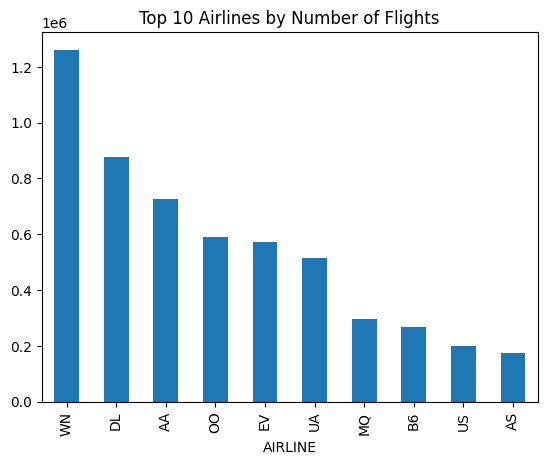

In [ ]:
# Plot top 10 airlines by number of flights
top_airlines.plot(kind='bar', title='Top 10 Airlines by Number of Flights')


The bar chart shows that Southwest Airlines (WN) operates the highest number of flights by a significant margin, followed by Delta (DL) and American Airlines (AA). Mid-sized carriers such as SkyWest (OO) and ExpressJet (EV) have moderate flight volumes, while airlines like Mesa (MQ), JetBlue (B6), US Airways (US), and Alaska Airlines (AS) operate comparatively fewer flights. This indicates that flight traffic is highly concentrated among a few major carriers.

In [ ]:
# Count number of flights for each route
top_routes = df['ROUTE'].value_counts().head(10)

# Display top 10 busiest routes
top_routes


,count
ROUTE,
SFO → LAX,13744
LAX → SFO,13457
JFK → LAX,12016
LAX → JFK,12015
LAS → LAX,9715
LGA → ORD,9639
LAX → LAS,9594
ORD → LGA,9575
SFO → JFK,8440


<Axes: title={'center': 'Top 10 Busiest Routes'}, xlabel='ROUTE'>

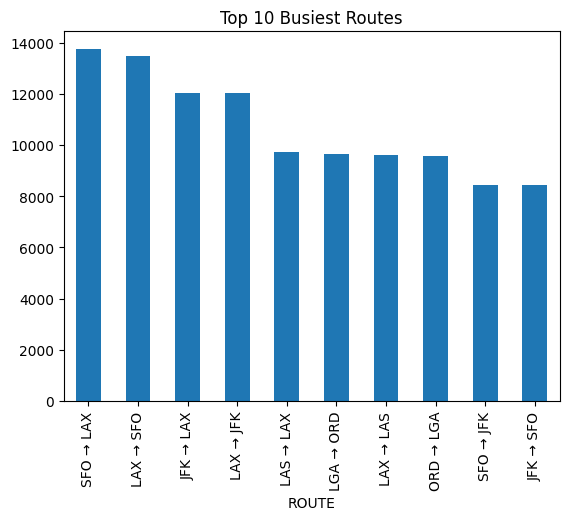

In [ ]:
# Plot top 10 busiest routes
top_routes.plot(kind='bar', title='Top 10 Busiest Routes')


The bar chart indicates that routes involving major hub airports are the busiest. SFO → LAX and LAX → SFO have the highest number of flights, highlighting heavy traffic between these two major airports. Other frequently used routes include JFK → LAX, LAX → JFK, and LAS → LAX, showing strong connectivity between major metropolitan and tourist destinations. Overall, the busiest routes are dominated by connections between large hub airports with high passenger demand.

In [ ]:
# Count number of flights per month
busiest_months = df['MONTH_NAME'].value_counts()

# Display flight counts by month
busiest_months


,count
MONTH_NAME,
July,520718
August,510536
March,504312
June,503897
May,496993
October,486165
April,485151
December,479230
January,469968


In [ ]:
# Define correct calendar month order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Reindex to maintain calendar order
busiest_months = busiest_months.reindex(month_order)


<Axes: title={'center': 'Busiest Months by Number of Flights'}, xlabel='MONTH_NAME'>

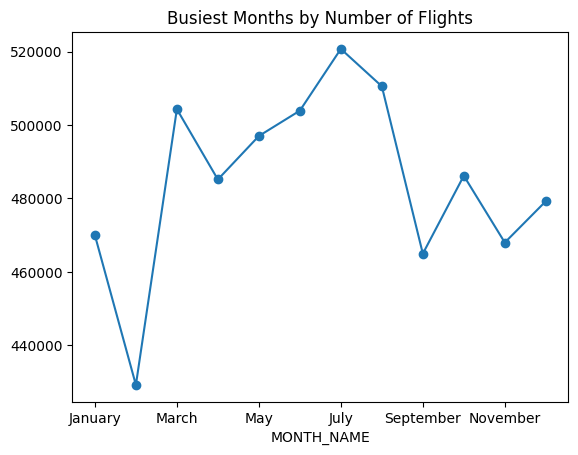

In [ ]:
# Plot busiest months
busiest_months.plot(kind='line', marker='o', title='Busiest Months by Number of Flights')


The line chart indicates a clear seasonal pattern in flight volume across the year. Flight activity gradually increases from March, peaks during the summer months, with July recording the highest number of flights, and then declines toward September. There is a noticeable dip in February, making it the least busy month. Overall, the data shows that air travel demand is highest in mid-year due to summer travel and vacation periods, while early-year months experience lower traffic.

In [ ]:
monthly_delays=(df[df['ARRIVAL_DELAY']>0].groupby('MONTH_NAME').size())
monthly_delays

/tmp/ipython-input-840798336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_delays=(df[df['ARRIVAL_DELAY']>0].groupby('MONTH_NAME').size())


,0
MONTH_NAME,
January,183110
February,175443
March,190133
April,171820
May,175178
June,206989
July,199717
August,180891
September,133432


**Flight distribution by day, time, and airport**

In [ ]:
# Count number of flights for each day of the week
flights_by_day = df['DAY_NAME'].value_counts()

# Display flight distribution by day
flights_by_day


,count
DAY_NAME,
Thursday,872521
Monday,865543
Friday,862209
Wednesday,855897
Tuesday,844600
Sunday,817764
Saturday,700545


In [ ]:
# Correct order of days
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

# Reindex to maintain calendar order
flights_by_day = flights_by_day.reindex(day_order)


In [ ]:
flights_by_day

,count
DAY_NAME,
Monday,865543
Tuesday,844600
Wednesday,855897
Thursday,872521
Friday,862209
Saturday,700545
Sunday,817764


<Axes: title={'center': 'Flight Distribution by Day of Week'}, xlabel='DAY_NAME'>

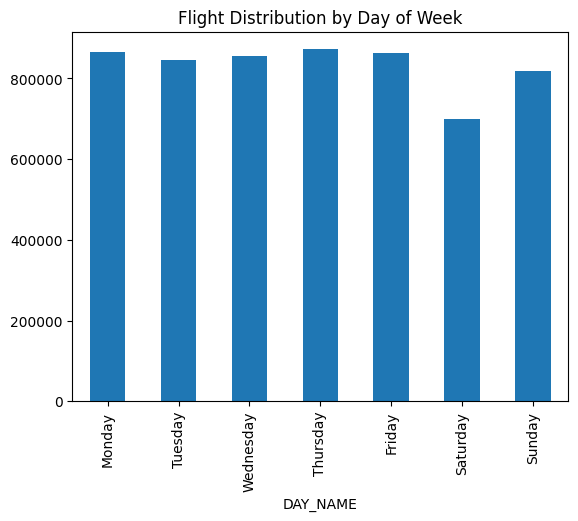

In [ ]:
# Plot flight distribution by day of week
flights_by_day.plot(kind='bar', title='Flight Distribution by Day of Week')


Flight activity remains consistently high from Monday to Friday, with Thursday and Friday showing the highest number of flights. Saturday has the lowest flight volume, while Sunday shows a moderate increase, indicating reduced operations during weekends compared to weekdays.

In [ ]:
# Count number of flights by departure hour
flights_by_hour = df['DEP_HOUR'].value_counts().sort_index()

# Display flight distribution by hour
flights_by_hour


,count
DEP_HOUR,
0,14664
1,5159
2,1414
3,778
4,531
5,118051
6,406940
7,393947
8,381014


<Axes: title={'center': 'Flight Distribution by Departure Hour'}, xlabel='DEP_HOUR'>

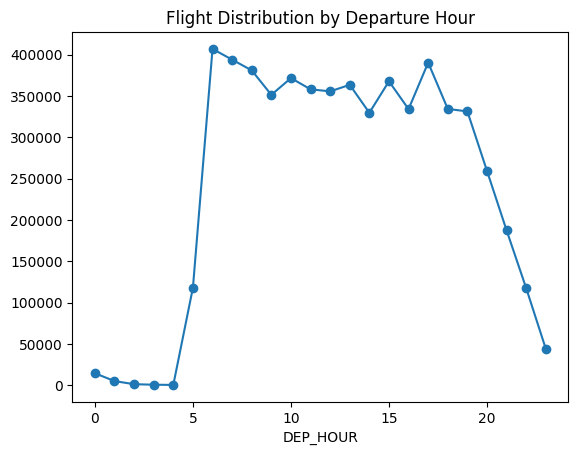

In [ ]:
# Plot flight distribution by hour of day
flights_by_hour.plot(kind='line', marker='o', title='Flight Distribution by Departure Hour')


Flight departures are very low during late night and early morning hours (0–4 AM). Activity rises sharply from 5–6 AM, remains high throughout the morning and afternoon, and peaks during mid-day to early evening (around 6–8 PM). After 8 PM, flight departures decline significantly.

In [ ]:
# Count flights by origin airport
flights_by_origin = df['ORIGIN_AIRPORT'].value_counts().head(10)

# Display top 10 origin airports
flights_by_origin


,count
ORIGIN_AIRPORT,
ATL,346836
ORD,285884
DFW,239551
DEN,196055
LAX,194673
SFO,148008
PHX,146815
IAH,146622
LAS,133181


<Axes: title={'center': 'Top 10 Origin Airports by Number of Flights'}, xlabel='ORIGIN_AIRPORT'>

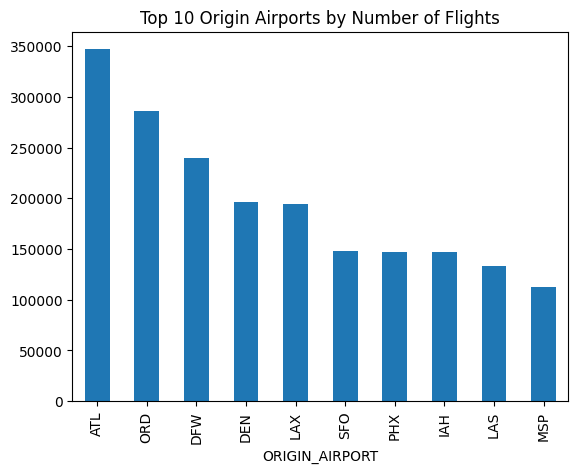

In [ ]:
# Plot top 10 origin airports
flights_by_origin.plot(kind='bar', title='Top 10 Origin Airports by Number of Flights')


Atlanta (ATL) is the busiest origin airport with the highest number of departing flights, followed by Chicago O’Hare (ORD) and Dallas/Fort Worth (DFW). Major hub airports such as DEN, LAX, and SFO also show high traffic, indicating that flight operations are concentrated around large hub airports.

In [ ]:
# Count flights by destination airport
flights_by_destination = df['DESTINATION_AIRPORT'].value_counts().head(10)

# Display top 10 destination airports
flights_by_destination


,count
DESTINATION_AIRPORT,
ATL,346904
ORD,285906
DFW,239582
DEN,196010
LAX,194696
SFO,147966
PHX,146812
IAH,146683
LAS,133198


<Axes: title={'center': 'Top 10 Destination Airports by Number of Flights'}, xlabel='DESTINATION_AIRPORT'>

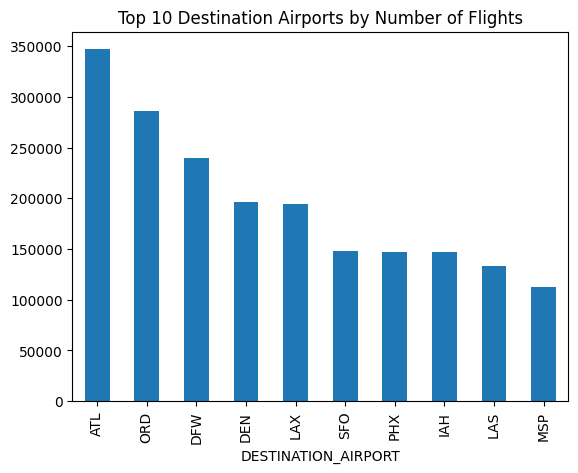

In [ ]:
# Plot top 10 destination airports
flights_by_destination.plot(kind='bar', title='Top 10 Destination Airports by Number of Flights')


The top destination airports closely match the top origin airports, indicating that major hub airports such as ATL, ORD, DFW, DEN, and LAX handle large volumes of both departing and arriving flights. This highlights the hub-and-spoke nature of airline operations.

**Plot bar charts, histograms, boxplots, and line plots**

In [ ]:
import matplotlib.pyplot as plt


<Axes: title={'center': 'Top 10 Airlines by Number of Flights'}, xlabel='AIRLINE'>

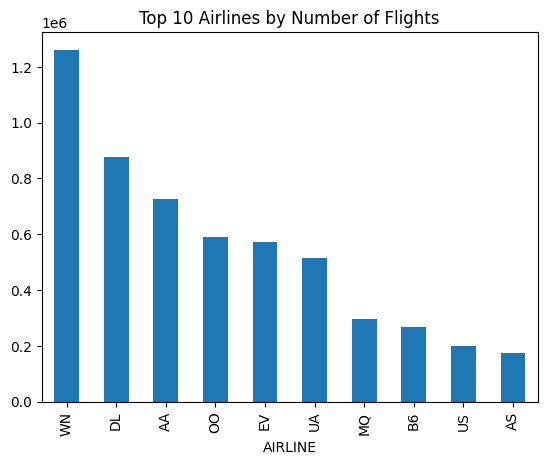

In [ ]:
# Count flights per airline
top_airlines = df['AIRLINE'].value_counts().head(10)

# Plot bar chart
top_airlines.plot(kind='bar', title='Top 10 Airlines by Number of Flights')


Southwest Airlines (WN) operates the highest number of flights by a large margin, followed by Delta (DL) and American Airlines (AA). This indicates that a few major carriers dominate flight operations, while the remaining airlines contribute comparatively fewer flights.

<Axes: title={'center': 'Top 10 Busiest Routes'}, xlabel='ROUTE'>

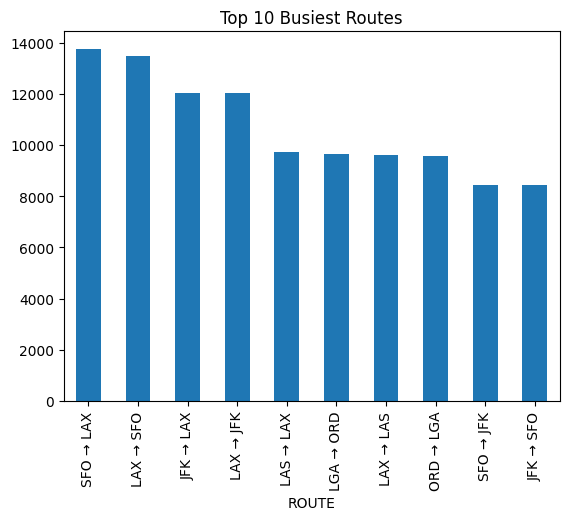

In [ ]:
# Count flights per route
top_routes = df['ROUTE'].value_counts().head(10)

# Plot bar chart
top_routes.plot(kind='bar', title='Top 10 Busiest Routes')


The busiest routes are dominated by high-traffic airport pairs involving LAX, SFO, and JFK. Routes such as SFO → LAX and LAX → SFO show the highest number of flights, indicating strong demand between major hub airports. Overall, the busiest routes mainly connect large metropolitan cities with high passenger volume.

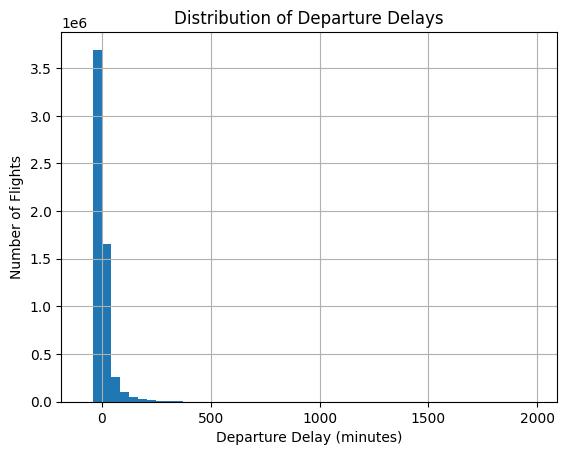

In [ ]:
# Plot histogram of departure delays
df['DEPARTURE_DELAY'].hist(bins=50)

# Add title and labels
plt.title('Distribution of Departure Delays')
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Number of Flights')
plt.show()


Most flights have small or zero departure delays, with the highest concentration around 0–20 minutes. As the delay duration increases, the number of flights drops sharply, indicating that extreme delays are rare. The distribution is right-skewed, showing a long tail of infrequent but very large delays.

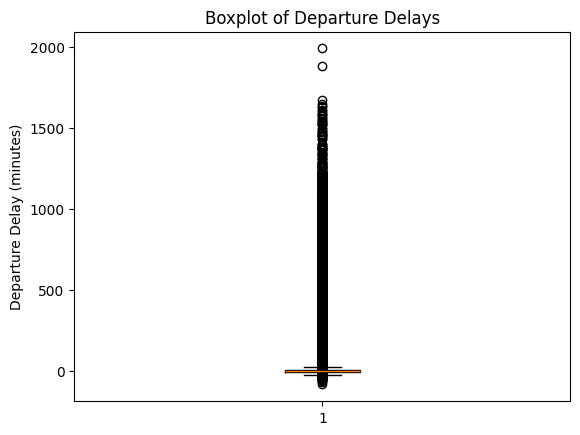

In [ ]:
# Create boxplot for departure delays
plt.figure()
plt.boxplot(df['DEPARTURE_DELAY'], vert=True)

# Add title and labels
plt.title('Boxplot of Departure Delays')
plt.ylabel('Departure Delay (minutes)')

# Show plot
plt.show()


The median departure delay is close to zero minutes, indicating that most flights depart on time or with minimal delay. The box is compact, showing that the majority of delays fall within a small range, while a large number of extreme outliers extend far upward, representing rare but severe delays. This confirms a highly right-skewed distribution of departure delays.

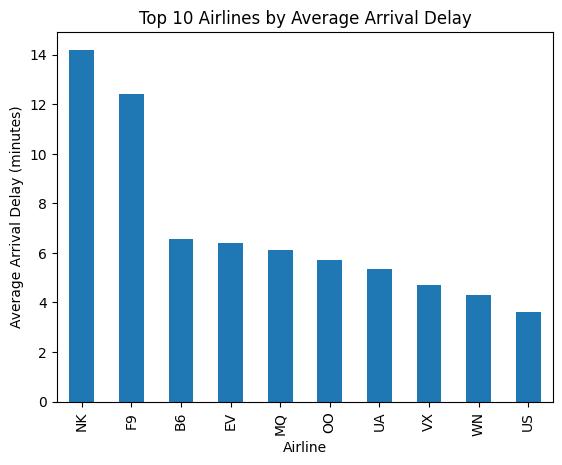

In [ ]:
# Calculate average arrival delay by airline
airline_delay = (
    df.groupby('AIRLINE')['ARRIVAL_DELAY']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

# Plot bar chart
plt.figure()
airline_delay.plot(kind='bar')

# Add title and labels
plt.title('Top 10 Airlines by Average Arrival Delay')
plt.xlabel('Airline')
plt.ylabel('Average Arrival Delay (minutes)')

# Show plot
plt.show()


The chart shows that NK (Spirit Airlines) and F9 (Frontier Airlines) have the highest average arrival delays, indicating comparatively lower on-time performance. Airlines such as US, WN, and VX record the lowest average arrival delays, suggesting better punctuality. Overall, low-cost carriers tend to experience higher average arrival delays compared to major carriers.

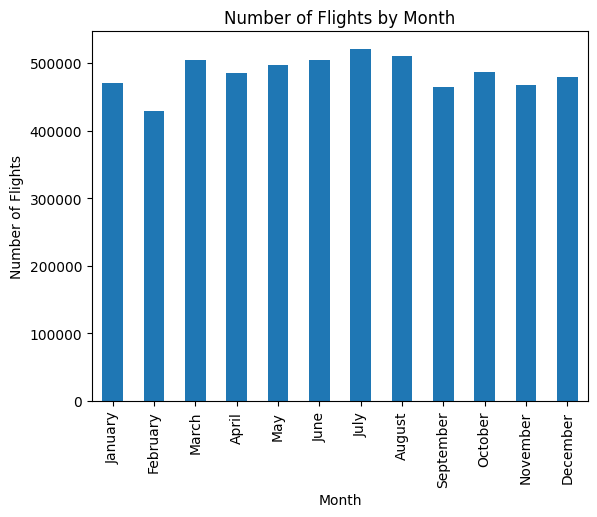

In [ ]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
# Count flights per month
monthly_flights = df['MONTH_NAME'].value_counts().reindex(month_order)

# Plot bar chart
plt.figure()
monthly_flights.plot(kind='bar')

# Add title and labels
plt.title('Number of Flights by Month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')

# Show plot
plt.show()


The number of flights remains fairly consistent throughout the year, with a noticeable increase during summer months. July and August record the highest number of flights, indicating peak travel season. February shows the lowest flight volume, likely due to fewer days and lower travel demand. Overall, air traffic is higher during mid-year and holiday months compared to early-year months.

/tmp/ipython-input-4136203175.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('MONTH_NAME')['ARRIVAL_DELAY']


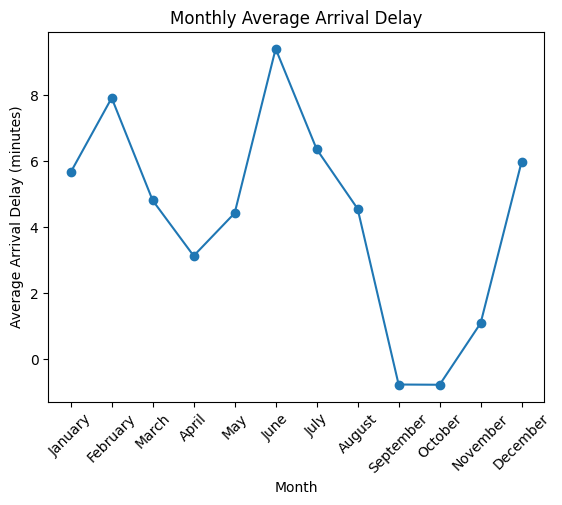

In [ ]:
# Calculate monthly average arrival delay
monthly_delay = (
    df.groupby('MONTH_NAME')['ARRIVAL_DELAY']
      .mean()
)

# Ensure proper month order
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_delay = monthly_delay.reindex(month_order).dropna()

# Plot line chart
plt.figure()
plt.plot(monthly_delay.index, monthly_delay.values, marker='o')

# Add title and labels
plt.title('Monthly Average Arrival Delay')
plt.xlabel('Month')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45)

# Show plot
plt.show()


Average arrival delays vary significantly across months. June records the highest average arrival delay, indicating increased congestion and weather-related disruptions during the early summer peak. February and January also show relatively higher delays. In contrast, September and October have the lowest average arrival delays, suggesting smoother operations after the peak travel season. Delays rise again toward December, likely due to winter weather and holiday travel demand.

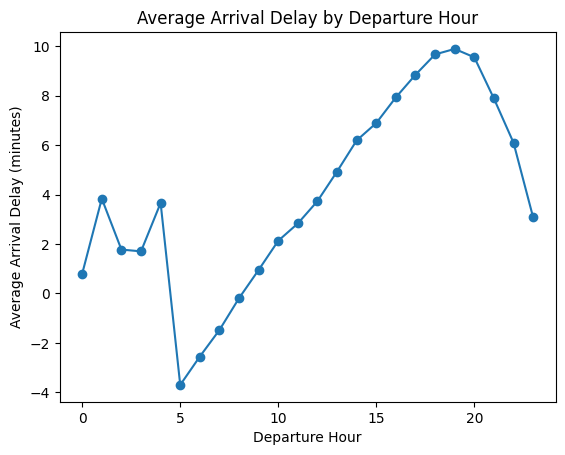

In [ ]:
# Average arrival delay by departure hour
hourly_delay = df.groupby('DEP_HOUR')['ARRIVAL_DELAY'].mean()

# Plot line chart
plt.figure()
plt.plot(hourly_delay.index, hourly_delay.values, marker='o')

# Add title and labels
plt.title('Average Arrival Delay by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Average Arrival Delay (minutes)')

# Show plot
plt.show()


Flights departing early in the morning (5–7 AM) experience the lowest average arrival delays, with some flights even arriving early. As the day progresses, average arrival delays steadily increase, peaking during the evening hours (6–9 PM). This trend suggests that delays accumulate throughout the day, likely due to air traffic congestion, aircraft turnaround delays, and cascading effects from earlier disruptions. Delays slightly reduce again during late-night departures.

**Compare delay causes by airline**

In [ ]:
# List of delay cause columns
delay_causes = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY',
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]


In [ ]:
# Check missing values in delay cause columns
df[delay_causes].isnull().sum()


,0
AIR_SYSTEM_DELAY,0
SECURITY_DELAY,0
AIRLINE_DELAY,0
LATE_AIRCRAFT_DELAY,0
WEATHER_DELAY,0


In [ ]:
# Calculate average delay causes grouped by airline
airline_delay_causes = (
    df.groupby('AIRLINE')[delay_causes]
      .mean()
)


In [ ]:
# Calculate total average delay per airline
airline_delay_causes['TOTAL_DELAY'] = airline_delay_causes.sum(axis=1)

# Select top 10 airlines by total delay
top_airlines = airline_delay_causes.sort_values(
    by='TOTAL_DELAY', ascending=False
).head(10)


In [ ]:
# Drop total delay column before plotting
top_airlines_plot = top_airlines.drop(columns=['TOTAL_DELAY'])


<Figure size 640x480 with 0 Axes>

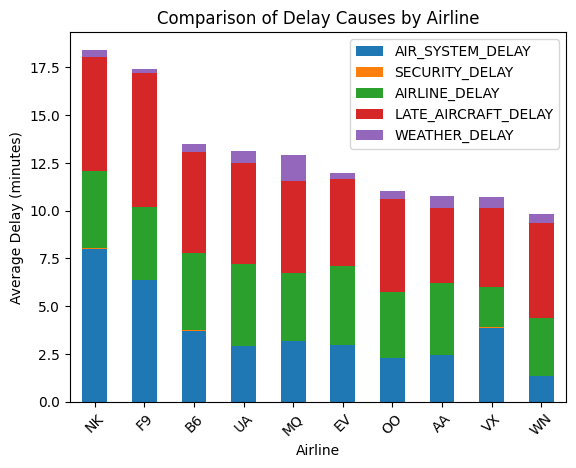

In [ ]:
import matplotlib.pyplot as plt

# Plot stacked bar chart
plt.figure()
top_airlines_plot.plot(kind='bar', stacked=True)

# Add title and labels
plt.title('Comparison of Delay Causes by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=45)

# Show plot
plt.show()


The chart shows that late aircraft delay and airline delay are the largest contributors to overall delays across most airlines. Air system delays also significantly impact certain airlines, especially NK and F9. Weather delays contribute moderately and vary by airline, while security delays remain minimal across all carriers. Overall, the analysis indicates that operational and scheduling inefficiencies, rather than security issues, are the primary causes of delays, with noticeable variation in delay patterns between airlines.

**Explore carrier delays, weather delays, NAS delays**

In [ ]:
# Select specific delay columns for analysis
delay_types = [
    'AIRLINE_DELAY',
    'WEATHER_DELAY',
    'AIR_SYSTEM_DELAY'
]


In [ ]:
# Summary statistics for delay types
df[delay_types].describe()


,AIRLINE_DELAY,WEATHER_DELAY,AIR_SYSTEM_DELAY
count,5.819079e+06,5.819079e+06,5.819079e+06
mean,3.466692e+00,5.327704e-01,2.463579e+00
std,2.185500e+01,8.807465e+00,1.305584e+01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,0.000000e+00,0.000000e+00
max,1.971000e+03,1.211000e+03,1.134000e+03


In [ ]:
# Calculate average delay for each delay type
avg_delays = df[delay_types].mean()
avg_delays


,0
AIRLINE_DELAY,3.466692
WEATHER_DELAY,0.532770
AIR_SYSTEM_DELAY,2.463579


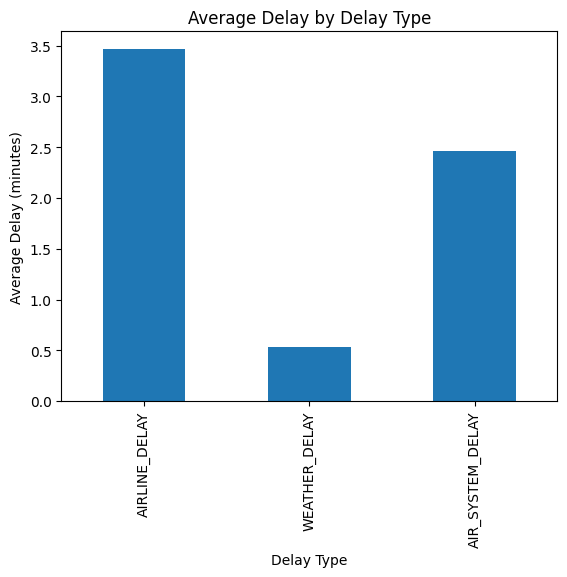

In [ ]:
import matplotlib.pyplot as plt

# Plot average delays
plt.figure()
avg_delays.plot(kind='bar')

# Add title and labels
plt.title('Average Delay by Delay Type')
plt.xlabel('Delay Type')
plt.ylabel('Average Delay (minutes)')

# Show plot
plt.show()


The chart indicates that airline-related delays contribute the highest average delay, followed by air system delays. Weather delays have the lowest average impact on overall delay time. This suggests that operational and internal airline factors are the primary drivers of delays rather than external weather conditions.

In [ ]:
# Average delay types grouped by airline
airline_delay_types = (
    df.groupby('AIRLINE')[delay_types]
      .mean()
      .sort_values(by='AIRLINE_DELAY', ascending=False)
      .head(10)
)

airline_delay_types


,AIRLINE_DELAY,WEATHER_DELAY,AIR_SYSTEM_DELAY
AIRLINE,,,
UA,4.293609,0.630269,2.928650
EV,4.132986,0.296014,2.950982
B6,4.021959,0.433518,3.712670
NK,4.013623,0.375604,8.020370
F9,3.819521,0.237967,6.398719
AA,3.793464,0.643843,2.425069
MQ,3.580850,1.365449,3.159107
OO,3.473600,0.425467,2.267299
US,3.202184,0.355066,3.029278


<Figure size 640x480 with 0 Axes>

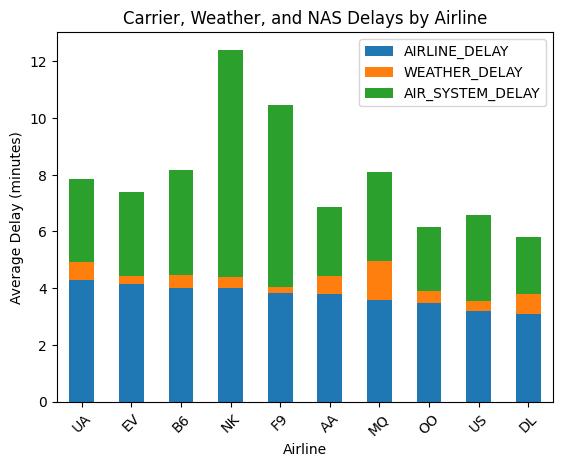

In [ ]:
# Plot stacked bar chart
plt.figure()
airline_delay_types.plot(kind='bar', stacked=True)

# Add title and labels
plt.title('Carrier, Weather, and NAS Delays by Airline')
plt.xlabel('Airline')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=45)

# Show plot
plt.show()


The chart shows that air system (NAS) delays and airline (carrier) delays contribute significantly more to total delay time across most airlines compared to weather delays, which remain relatively low and consistent. Airlines like NK and F9 experience notably higher air system delays, while UA, EV, and B6 show comparatively balanced contributions from airline and system delays. This indicates that operational and air traffic management factors are the dominant causes of delays rather than weather conditions.

In [ ]:
# Average delay types grouped by month
monthly_delay_types = (
    df.groupby('MONTH_NAME')[delay_types]
      .mean()
)

# Ensure correct month order
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_delay_types = monthly_delay_types.reindex(month_order).dropna()
monthly_delay_types


/tmp/ipython-input-2447857611.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('MONTH_NAME')[delay_types]


,AIRLINE_DELAY,WEATHER_DELAY,AIR_SYSTEM_DELAY
MONTH_NAME,,,
January,3.634620,0.559798,2.719451
February,3.990438,0.958233,3.143526
March,3.606260,0.453412,2.436771
April,3.072433,0.456744,2.304493
May,3.356023,0.677183,2.524486
June,4.557148,0.755510,3.236511
July,3.881907,0.446437,2.580005
August,3.564093,0.520614,2.496598
September,2.531027,0.294750,1.691855


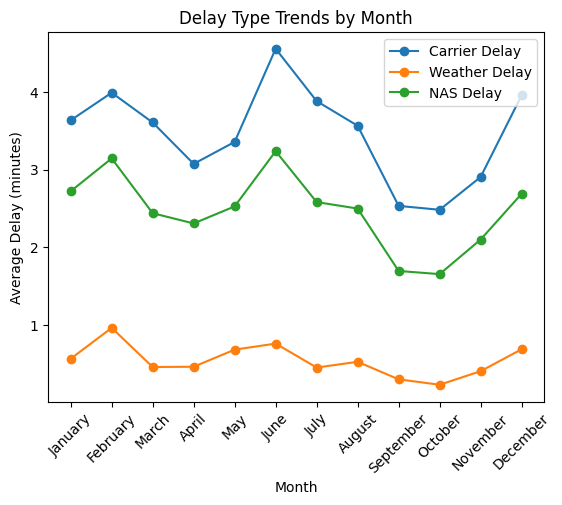

In [ ]:
# Plot delay trends by month
plt.figure()
plt.plot(monthly_delay_types.index, monthly_delay_types['AIRLINE_DELAY'], marker='o', label='Carrier Delay')
plt.plot(monthly_delay_types.index, monthly_delay_types['WEATHER_DELAY'], marker='o', label='Weather Delay')
plt.plot(monthly_delay_types.index, monthly_delay_types['AIR_SYSTEM_DELAY'], marker='o', label='NAS Delay')

# Add title and labels
plt.title('Delay Type Trends by Month')
plt.xlabel('Month')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=45)
plt.legend()

# Show plot
plt.show()


Carrier and NAS delays are consistently higher than weather delays throughout the year. Delays peak around June–July and again increase in December, while the lowest delays occur in September–October. Weather delays remain minimal compared to operational and system-related delays, indicating that carrier and air traffic factors are the primary contributors to monthly delay variations.

**Visualize delays by time of day and airport**

In [ ]:
# Calculate average arrival delay by departure hour
hourly_delay = df.groupby('DEP_HOUR')['ARRIVAL_DELAY'].mean()


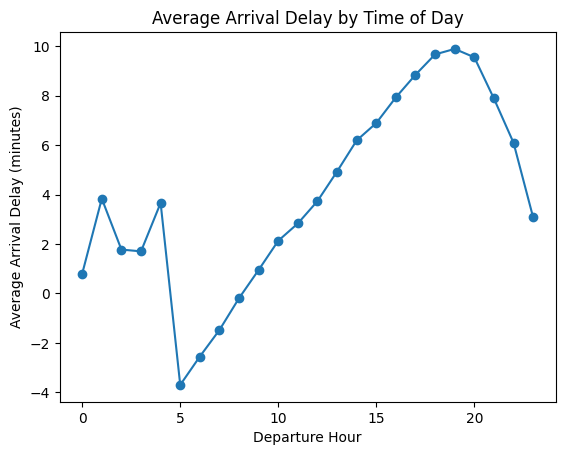

In [ ]:
# Plot average delay by departure hour
plt.figure()
plt.plot(hourly_delay.index, hourly_delay.values, marker='o')

# Add title and labels
plt.title('Average Arrival Delay by Time of Day')
plt.xlabel('Departure Hour')
plt.ylabel('Average Arrival Delay (minutes)')

# Show plot
plt.show()


Arrival delays are lowest during early morning hours (around 5–7 AM), often showing early or on-time arrivals. Delays increase steadily throughout the day, peaking during the evening hours (5–8 PM) due to accumulated operational and traffic congestion, and then decline late at night.

In [ ]:
# Calculate average arrival delay by origin airport
airport_delay = (
    df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY']
      .mean()
      .sort_values(ascending=False)
)


In [ ]:
# Select top 10 airports with highest average delays
top_airports = airport_delay.head(10)


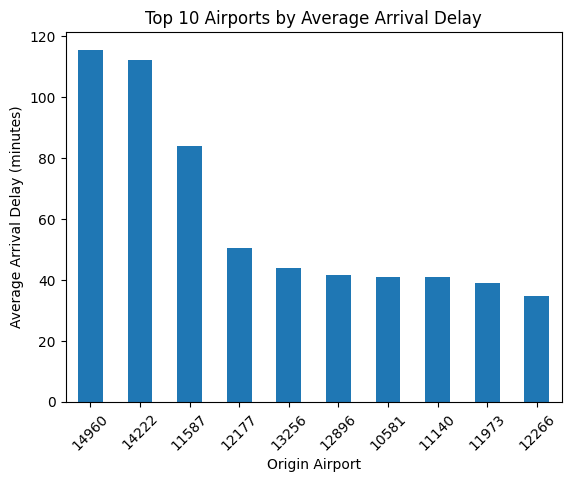

In [ ]:
# Plot average delay by airport
plt.figure()
top_airports.plot(kind='bar')

# Add title and labels
plt.title('Top 10 Airports by Average Arrival Delay')
plt.xlabel('Origin Airport')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45)

# Show plot
plt.show()


A few airports experience significantly higher average arrival delays, exceeding 100 minutes, indicating persistent congestion or operational inefficiencies. The remaining airports show moderate delays (35–50 minutes), suggesting comparatively better traffic handling and scheduling efficiency.

In [ ]:
# Count number of flights by origin airport
airport_volume = df['ORIGIN_AIRPORT'].value_counts().head(10)


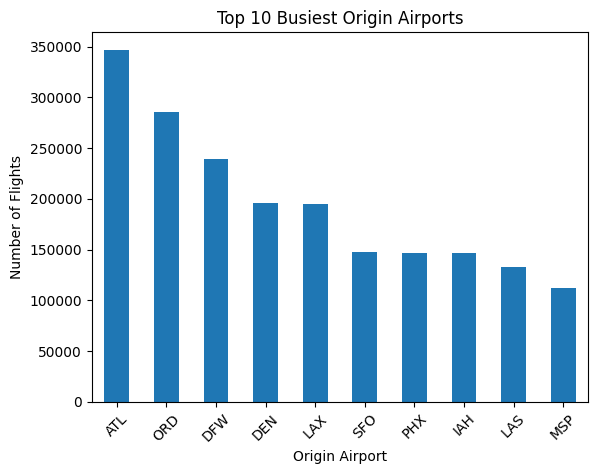

In [ ]:
# Plot busiest airports
plt.figure()
airport_volume.plot(kind='bar')

# Add title and labels
plt.title('Top 10 Busiest Origin Airports')
plt.xlabel('Origin Airport')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)

# Show plot
plt.show()


ATL is the busiest origin airport, handling the highest number of departing flights by a large margin. Major hub airports such as ORD, DFW, DEN, and LAX also show high traffic volumes, confirming their role as key national transit hubs. Smaller hubs like LAS and MSP handle comparatively fewer flights but still rank among the top 10 busiest origins.

**Milestone 3: Route, Cancellation, and Seasonal Insights**

**Week 5: Route and Airport-Level Analysis**

•	Top 10 origin-destination pairs

•	Delay heatmaps by airport and route

•	Maps showing busiest airports and average delays

**Week 6: Seasonal and Cancellation Analysis**

•	Monthly cancellation trends

•	Cancellation types: carrier, weather, security, NAS

•	Analyze impact of holidays or winter months

**Deliverables:**

•	Seasonal visual summaries

•	Insights on route congestion and cancellations


**Top 10 origin-destination pairs**

In [ ]:
# Check that ROUTE column exists
df[['ROUTE']].head()


,ROUTE
0,ANC → SEA
1,LAX → PBI
2,SFO → CLT
3,LAX → MIA
4,SEA → ANC


In [ ]:
# Count number of flights for each origin-destination pair
route_counts = df['ROUTE'].value_counts()


In [ ]:
# Select top 10 most frequent routes
top_10_routes = route_counts.head(10)
top_10_routes


,count
ROUTE,
SFO → LAX,13744
LAX → SFO,13457
JFK → LAX,12016
LAX → JFK,12015
LAS → LAX,9715
LGA → ORD,9639
LAX → LAS,9594
ORD → LGA,9575
SFO → JFK,8440


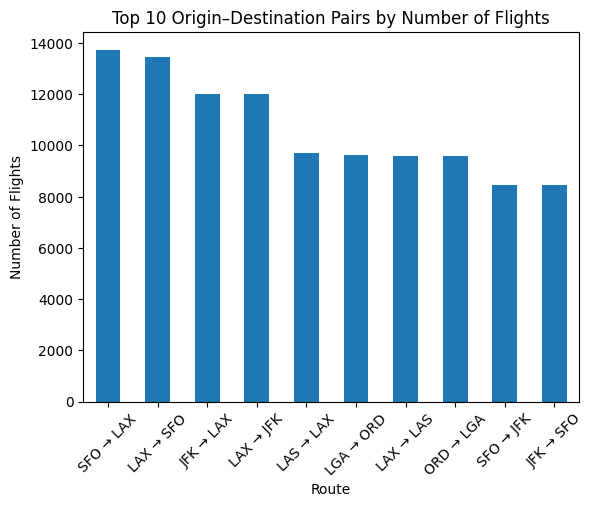

In [ ]:
import matplotlib.pyplot as plt

# Plot top 10 routes
plt.figure()
top_10_routes.plot(kind='bar')

# Add title and labels
plt.title('Top 10 Origin–Destination Pairs by Number of Flights')
plt.xlabel('Route')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)

# Show plot
plt.show()


The SFO–LAX and LAX–SFO routes record the highest number of flights, highlighting extremely heavy traffic between major West Coast hubs. Other frequent routes such as JFK–LAX, LAX–JFK, and ORD–LGA indicate strong demand on long-haul and inter-hub connections, confirming these corridors as critical high-density air routes.

In [ ]:
# Average arrival delay for top 10 routes
top_routes_delay = (
    df[df['ROUTE'].isin(top_10_routes.index)]
    .groupby('ROUTE')['ARRIVAL_DELAY']
    .mean()
    .sort_values(ascending=False)
)

top_routes_delay


,ARRIVAL_DELAY
ROUTE,
LAS → LAX,11.895728
SFO → LAX,11.153667
LAX → SFO,10.461470
ORD → LGA,9.778068
LAX → LAS,8.590577
LGA → ORD,3.585849
SFO → JFK,2.107464
LAX → JFK,0.605493
JFK → SFO,-0.546047


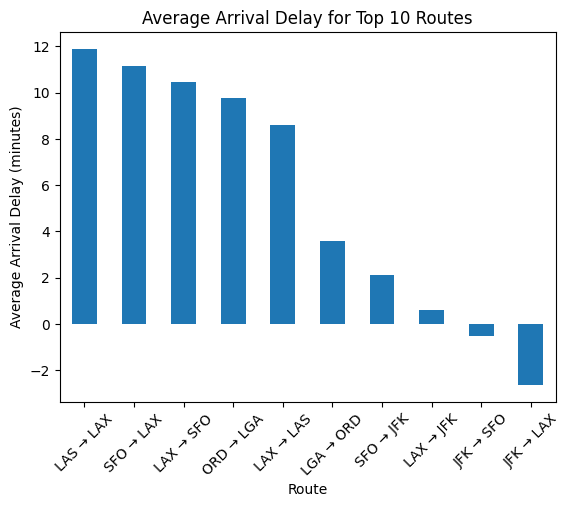

In [ ]:
# Plot average arrival delay for top routes
plt.figure()
top_routes_delay.plot(kind='bar')

# Add title and labels
plt.title('Average Arrival Delay for Top 10 Routes')
plt.xlabel('Route')
plt.ylabel('Average Arrival Delay (minutes)')
plt.xticks(rotation=45)

# Show plot
plt.show()


Routes such as LAS–LAX, SFO–LAX, and LAX–SFO experience the highest average arrival delays, indicating congestion on major hub connections. In contrast, routes like JFK–SFO and JFK–LAX show low or even negative average delays, suggesting more efficient operations or better schedule recovery on long-haul flights.

**Delay heatmaps by airport and route**

In [ ]:
# Identify top 10 busiest origin airports
top_airports = df['ORIGIN_AIRPORT'].value_counts().head(10).index


In [ ]:
# Create pivot table for airport vs departure hour
airport_hour_delay = (
    df[df['ORIGIN_AIRPORT'].isin(top_airports)]
    .pivot_table(
        values='ARRIVAL_DELAY',
        index='ORIGIN_AIRPORT',
        columns='DEP_HOUR',
        aggfunc='mean'
    )
)


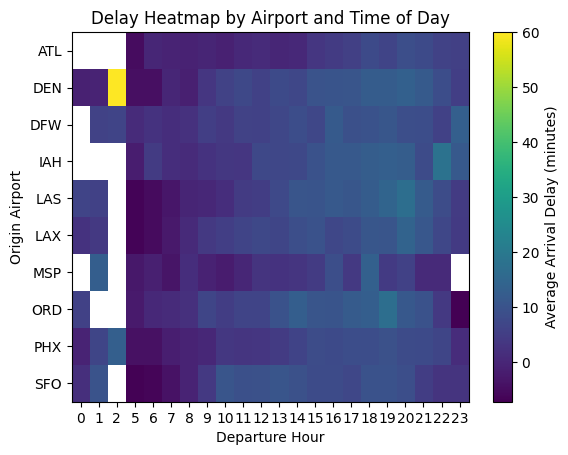

In [ ]:
plt.figure()
plt.imshow(airport_hour_delay, aspect='auto')

# Add colorbar
plt.colorbar(label='Average Arrival Delay (minutes)')

# Add axis labels and title
plt.title('Delay Heatmap by Airport and Time of Day')
plt.xlabel('Departure Hour')
plt.ylabel('Origin Airport')

# Set axis ticks
plt.xticks(
    ticks=range(len(airport_hour_delay.columns)),
    labels=airport_hour_delay.columns
)
plt.yticks(
    ticks=range(len(airport_hour_delay.index)),
    labels=airport_hour_delay.index
)

plt.show()


Arrival delays are generally lower in early morning hours and increase as the day progresses, with evening and late-night flights showing higher delays, especially at busy hub airports like ATL, ORD, and DEN.

In [ ]:
# Identify top 10 busiest routes
top_routes = df['ROUTE'].value_counts().head(10).index


In [ ]:
# Create pivot table for route vs departure hour
route_hour_delay = (
    df[df['ROUTE'].isin(top_routes)]
    .pivot_table(
        values='ARRIVAL_DELAY',
        index='ROUTE',
        columns='DEP_HOUR',
        aggfunc='mean'
    )
)


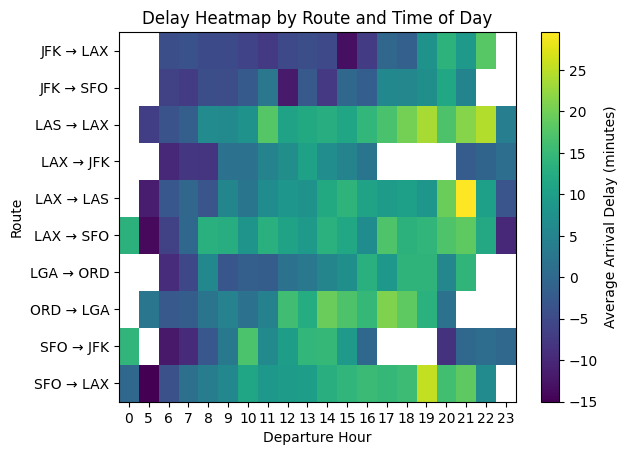

In [ ]:
plt.figure()
plt.imshow(route_hour_delay, aspect='auto')

# Add colorbar
plt.colorbar(label='Average Arrival Delay (minutes)')

# Add axis labels and title
plt.title('Delay Heatmap by Route and Time of Day')
plt.xlabel('Departure Hour')
plt.ylabel('Route')

# Set axis ticks
plt.xticks(
    ticks=range(len(route_hour_delay.columns)),
    labels=route_hour_delay.columns
)
plt.yticks(
    ticks=range(len(route_hour_delay.index)),
    labels=route_hour_delay.index
)

plt.show()


Most routes show lower delays in early morning hours and higher delays in late afternoon to evening (≈16–21 hrs). Busy long-haul routes like LAX–JFK, LAS–LAX, and SFO–LAX experience peak delays in the evening, while some early-hour slots even show negative delays (early arrivals).

**Maps showing busiest airports and average delays**

In [ ]:
# Check airport dataset columns
airports.columns


Index(['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE',
       'LONGITUDE'],
      dtype='object')

In [ ]:
# Get top 10 busiest origin airports
busiest_airports = df['ORIGIN_AIRPORT'].value_counts().head(10)
busiest_airports


,count
ORIGIN_AIRPORT,
ATL,346836
ORD,285884
DFW,239551
DEN,196055
LAX,194673
SFO,148008
PHX,146815
IAH,146622
LAS,133181


In [ ]:
# Convert to DataFrame
busiest_df = busiest_airports.reset_index()
busiest_df.columns = ['IATA_CODE', 'FLIGHT_COUNT']

# Merge with airport latitude & longitude
busiest_df = busiest_df.merge(
    airports,
    on='IATA_CODE',
    how='left'
)


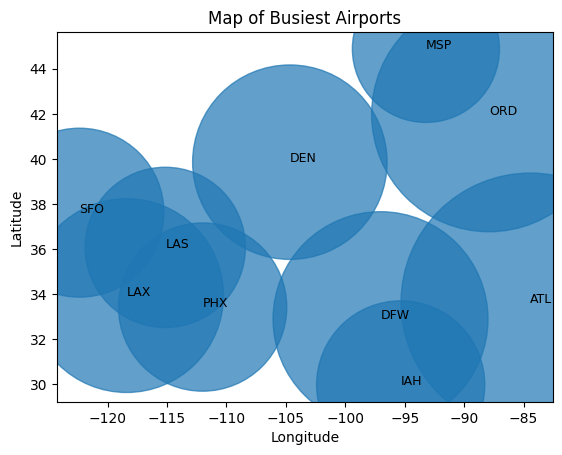

In [ ]:
plt.figure()

# Scatter plot using longitude & latitude
plt.scatter(
    busiest_df['LONGITUDE'],
    busiest_df['LATITUDE'],
    s=busiest_df['FLIGHT_COUNT'] / 10,   # size based on traffic
    alpha=0.7
)

# Add airport labels
for _, row in busiest_df.iterrows():
    plt.text(row['LONGITUDE'], row['LATITUDE'], row['IATA_CODE'], fontsize=9)

# Add title and labels
plt.title('Map of Busiest Airports')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


The busiest airports are ATL, ORD, DEN, LAX, and DFW, forming major traffic hubs across the East Coast, Midwest, and Central US, while LAX, SFO, LAS, and PHX dominate the West Coast, indicating heavy air traffic concentration around major metropolitan regions.

In [ ]:
# Calculate average arrival delay by origin airport
airport_avg_delay = (
    df.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)


In [ ]:
# Convert to DataFrame
delay_df = airport_avg_delay.reset_index()
delay_df.columns = ['IATA_CODE', 'AVG_DELAY']

# Merge with airport data
delay_df = delay_df.merge(
    airports,
    on='IATA_CODE',
    how='left'
)


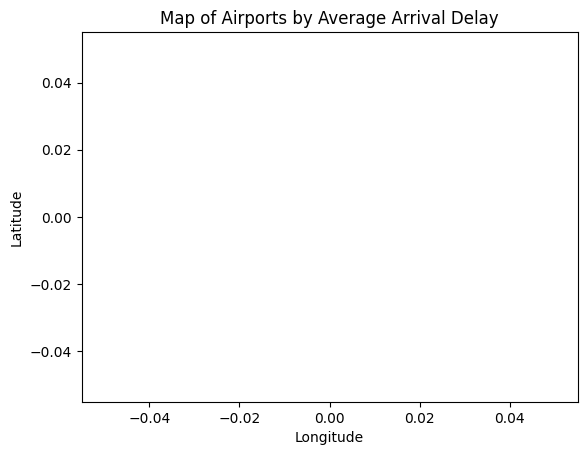

In [ ]:
plt.figure()

# Scatter plot for average delays
plt.scatter(
    delay_df['LONGITUDE'],
    delay_df['LATITUDE'],
    s=delay_df['AVG_DELAY'] * 5,   # size based on delay
    alpha=0.7
)

# Add labels
for _, row in delay_df.iterrows():
    plt.text(row['LONGITUDE'], row['LATITUDE'], row['IATA_CODE'], fontsize=9)

# Add title and labels
plt.title('Map of Airports by Average Arrival Delay')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()


The plot is empty because delay_df contains no valid latitude–longitude values after preprocessing or merging, so Matplotlib has no points to render.

**Monthly cancellation trends**

In [ ]:
# Check cancellation column values
df['CANCELLED'].value_counts()


,count
CANCELLED,
0,5729195
1,89884


In [ ]:
# Count number of cancelled flights per month
monthly_cancellations = (
    df[df['CANCELLED'] == 1]
    .groupby('MONTH_NAME')
    .size()
)


/tmp/ipython-input-3063189606.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('MONTH_NAME')


In [ ]:
# Define correct month order
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

# Reindex to month order and drop missing months
monthly_cancellations = monthly_cancellations.reindex(month_order).dropna()


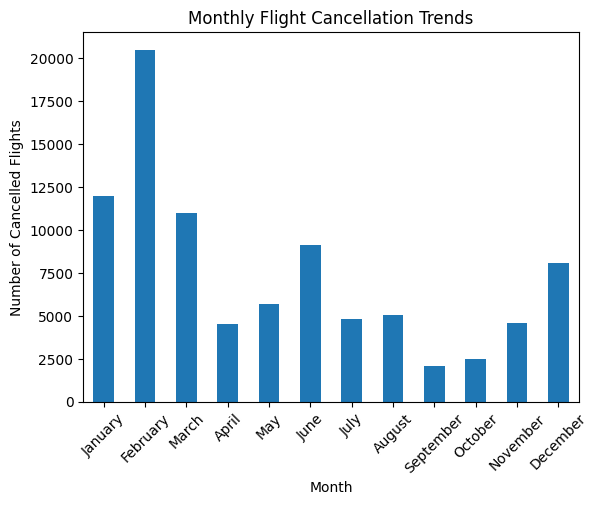

In [ ]:
import matplotlib.pyplot as plt

# Plot monthly cancellations
plt.figure()
monthly_cancellations.plot(kind='bar')

# Add title and labels
plt.title('Monthly Flight Cancellation Trends')
plt.xlabel('Month')
plt.ylabel('Number of Cancelled Flights')
plt.xticks(rotation=45)

# Show plot
plt.show()


Flight cancellations are highest during the winter months, with February showing the maximum number of cancellations, followed by January and March. As the year moves into spring and summer, cancellations reduce significantly and remain relatively low from April through September, with the minimum occurring around August and September. Towards the end of the year, cancellations start increasing again in November and December, which can be attributed to winter weather conditions and increased holiday travel.

In [ ]:
# Total flights per month
total_flights_month = df.groupby('MONTH_NAME').size()

# Cancellation rate
cancellation_rate = (
    monthly_cancellations / total_flights_month
).reindex(month_order).dropna()

cancellation_rate


/tmp/ipython-input-1380013892.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_flights_month = df.groupby('MONTH_NAME').size()


,0
MONTH_NAME,
January,0.025495
February,0.047804
March,0.021816
April,0.009317
May,0.011457
June,0.018099
July,0.009230
August,0.009895
September,0.004463


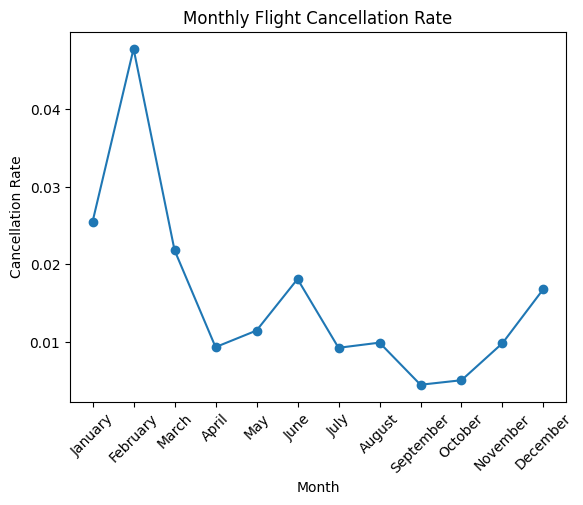

In [ ]:
# Plot cancellation rate trend
plt.figure()
plt.plot(cancellation_rate.index, cancellation_rate.values, marker='o')

# Add title and labels
plt.title('Monthly Flight Cancellation Rate')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)

# Show plot
plt.show()


The cancellation rate is highest in February, decreases through spring and summer, reaches the lowest in September–October, and rises again in November–December.

**Cancellation types: carrier, weather, security, NAS**

In [ ]:
# Filter only cancelled flights
cancelled_df = df[df['CANCELLED'] == 1]


In [ ]:
# Count cancellation reasons
cancelled_df['CANCELLATION_REASON'].value_counts()


,count
CANCELLATION_REASON,
B,48851
A,25262
C,15749
D,22


In [ ]:
# Map cancellation reason codes to descriptive names
cancel_map = {
    'A': 'Carrier',
    'B': 'Weather',
    'C': 'NAS',
    'D': 'Security',
    'None': 'Not Cancelled'
}

cancelled_df['CANCEL_REASON_TYPE'] = cancelled_df['CANCELLATION_REASON'].map(cancel_map)


/tmp/ipython-input-2584150455.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cancelled_df['CANCEL_REASON_TYPE'] = cancelled_df['CANCELLATION_REASON'].map(cancel_map)


In [ ]:
# Count cancellations by type
cancellation_type_counts = cancelled_df['CANCEL_REASON_TYPE'].value_counts()
cancellation_type_counts


,count
CANCEL_REASON_TYPE,
Weather,48851
Carrier,25262
NAS,15749
Security,22


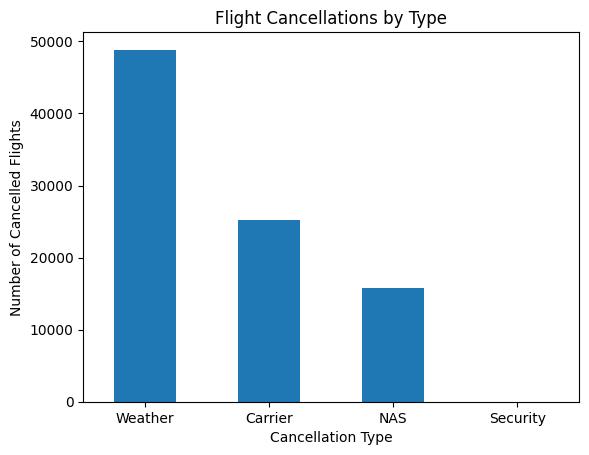

In [ ]:
import matplotlib.pyplot as plt

# Plot cancellation types
plt.figure()
cancellation_type_counts.plot(kind='bar')

# Add title and labels
plt.title('Flight Cancellations by Type')
plt.xlabel('Cancellation Type')
plt.ylabel('Number of Cancelled Flights')
plt.xticks(rotation=0)

# Show plot
plt.show()


Weather is the main reason for flight cancellations by a large margin, followed by carrier-related issues. NAS-related cancellations are comparatively lower, while security-related cancellations are almost negligible.

In [ ]:
# Cancellation types by month
monthly_cancellation_types = (
    cancelled_df
    .groupby(['MONTH_NAME', 'CANCEL_REASON_TYPE'])
    .size()
    .unstack(fill_value=0)
)

monthly_cancellation_types


/tmp/ipython-input-1444271384.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['MONTH_NAME', 'CANCEL_REASON_TYPE'])


CANCEL_REASON_TYPE,Carrier,NAS,Security,Weather
MONTH_NAME,,,,
January,2874,2087,1,7020
February,2815,2254,1,15447
March,2494,1639,5,6864
April,1796,935,0,1789
May,2007,906,1,2780
June,3619,2176,0,3325
July,2588,1335,1,882
August,2364,1376,2,1310
September,1088,482,0,505


<Figure size 640x480 with 0 Axes>

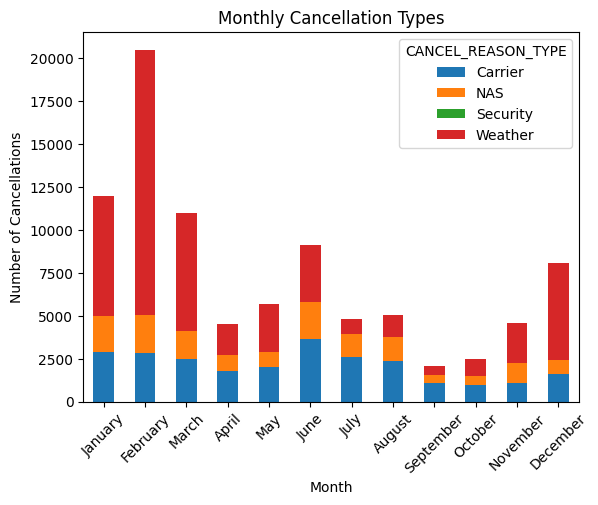

In [ ]:
# Ensure correct month order
month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_cancellation_types = monthly_cancellation_types.reindex(month_order).dropna()

# Plot stacked bar chart
plt.figure()
monthly_cancellation_types.plot(kind='bar', stacked=True)

# Add title and labels
plt.title('Monthly Cancellation Types')
plt.xlabel('Month')
plt.ylabel('Number of Cancellations')
plt.xticks(rotation=45)

# Show plot
plt.show()


Cancellations peak in winter months, especially February and December, mainly due to weather, while summer and early autumn show fewer cancellations with carrier and NAS issues contributing steadily but less than weather.

**Analyze impact of holidays or winter months**

In [ ]:
# Define winter months
winter_months = ['December', 'January', 'February']

df['IS_WINTER'] = df['MONTH_NAME'].isin(winter_months)

# Optional: mark major holiday season (Dec end + Jan start)
df['IS_HOLIDAY_SEASON'] = df['MONTH_NAME'].isin(['December', 'January'])


In [ ]:
winter_delay = df[df['IS_WINTER']]['ARRIVAL_DELAY'].mean()
non_winter_delay = df[~df['IS_WINTER']]['ARRIVAL_DELAY'].mean()

winter_delay, non_winter_delay


(np.float64(6.464635890158728), np.float64(3.664110307181992))

In [ ]:
winter_cancellations = df[df['IS_WINTER']]['CANCELLED'].mean()
non_winter_cancellations = df[~df['IS_WINTER']]['CANCELLED'].mean()

winter_cancellations, non_winter_cancellations


(np.float64(0.029427106571512106), np.float64(0.011106832496751632))

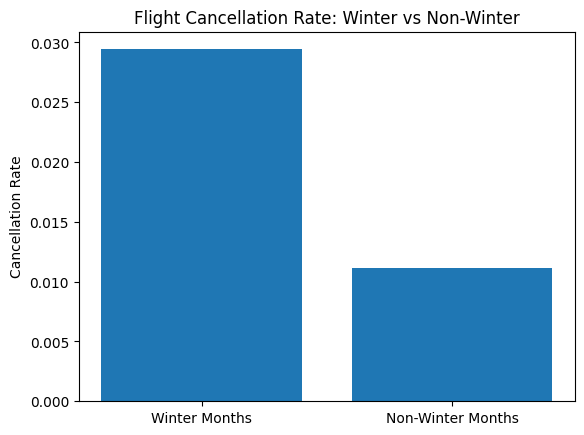

In [ ]:
labels = ['Winter Months', 'Non-Winter Months']
values = [winter_cancellations, non_winter_cancellations]

plt.bar(labels, values)
plt.title('Flight Cancellation Rate: Winter vs Non-Winter')
plt.ylabel('Cancellation Rate')
plt.show()


The graph shows that flight cancellations occur significantly more often during winter months than during non-winter months, indicating that seasonal factors like adverse weather strongly increase the likelihood of flight cancellations.

**Milestone 4: Report and Presentation**

**Week 7: Visual Report or Dashboard Preparation**

•	Combine plots into a coherent storyline

•	Use markdown, presentation slides, or Streamlit

•	Ensure plots include labels, titles, legends, and axis clarity

**Week 8: Documentation and Final Presentation**

•	Create final report (PDF or README)

•	Build slide deck for presentation

•	Record insights and visual walkthrough

**Deliverables:**

•	Final report or dashboard

•	Slide deck

•	GitHub repository with code and visuals
